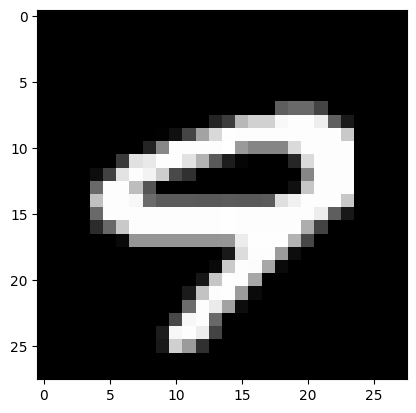

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

"""Import data and organize it in numpy arrays"""
data = pd.read_csv('MNIST_data/mnist_train.csv')  # import MNIST training data (CSV format)
labels = np.array(data.iloc[:,0])                 # first column = digit labels (0–9)
x_train = np.array(data.iloc[:,1:])/255           # remaining columns = pixel values, normalized to [0,1]

# One-hot encode labels
encoded_labels = []
for i in range(len(labels)):
    naked = [0,0,0,0,0,0,0,0,0,0]   # initialize vector of zeros (10 classes)
    naked[labels[i]] = 1            # set the true digit index to 1
    encoded_labels.append(naked)

"""Take a look at what the images look like"""
random_index = np.random.randint(0,40000)     # pick a random index
img = x_train[random_index].reshape(28,28)    # reshape 784 pixels into 28×28 image
plt.imshow(img, cmap="gray")                  # visualize image in grayscale

class DNN():  # Define a simple feedforward neural network as class
    def __init__(self, layers):
        self.layers = layers
        self.weights = []
        for i in range(len(layers)-1):
            # initialize random weights for each layer (+1 for bias term)
            layers_weights = np.random.rand(layers[i+1], layers[i]+1)
            self.weights.append(layers_weights)

    def sigmoid(self, x):
        # activation function (scaled sigmoid)
        return 1/(1+np.exp(-.01*x))

    def predict(self, data):
        x_s = [data]  # store intermediate activations

        for i in range(len(self.layers)-1):
            """add bias"""
            x_s[-1] = np.concatenate((x_s[-1], [1]))    # append bias term
            z = np.dot(self.weights[i], x_s[i])         # weighted sum
            x_s.append(self.sigmoid(z))                 # activation

        return x_s[-1]  # final layer output

    def train(self, data, y_true):
        # forward pass (same as predict, but keep activations for backprop)
        x_s = [data]
        for i in range(len(self.layers)-1):
            x_s[-1] = np.concatenate((x_s[-1], [1]))    # add bias
            z = np.dot(self.weights[i], x_s[i])         # weighted input
            x_s.append(self.sigmoid(z))                 # activation

        # compute error gradient for output layer (psi)
        psi = []
        for i in range(len(y_true)):
            output = x_s[-1][i]
            psi.append(-2*(y_true[i] - output) * (output * (1-output)))
        psi = np.array(psi).reshape((len(y_true),1))

        # compute gradients for output layer
        gradients = []
        gradients.append(psi*x_s[-2])   # outer product with last hidden layer

        # backpropagation loop for hidden layers
        for i in range(len(self.layers) - 2, 0, -1):
            w = self.weights[i][:,:-1]          # ignore bias weights
            x = x_s[i][:-1]                     # exclude bias input
            term = w * x * (1-x)                # derivative term
            term = np.transpose(term)

            psi = np.dot(term, psi)             # backpropagate error
            psi = psi.reshape((psi.shape[0],1))
            gradients.append(psi*x_s[i-1])      # gradient for this layer

        # update weights using computed gradients (learning rate = 0.1)
        for i in range(len(gradients)):
            self.weights[i] -= .1*gradients[-(i+1)]
        return sum((y_true-x_s[-1])**2)         # return squared error loss
            
# Initialize model with 784 input neurons, 1250 hidden neurons, and 10 outputs
model = DNN([784,1250,10])



Step: 1000
Average Error: 1.3942622089998893


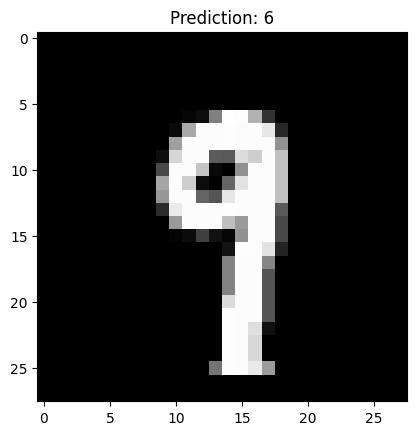


Step: 2000
Average Error: 0.8999058706681425


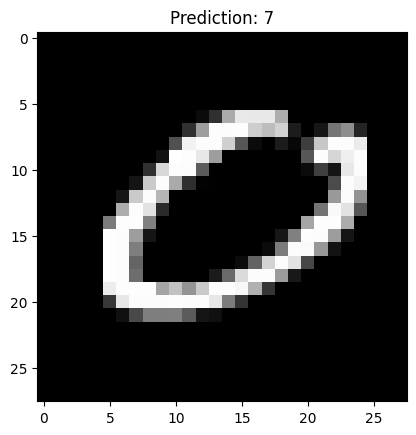


Step: 3000
Average Error: 0.897721196850834


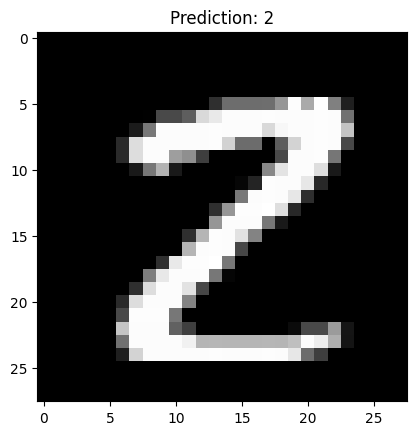


Step: 4000
Average Error: 0.8924506358938477


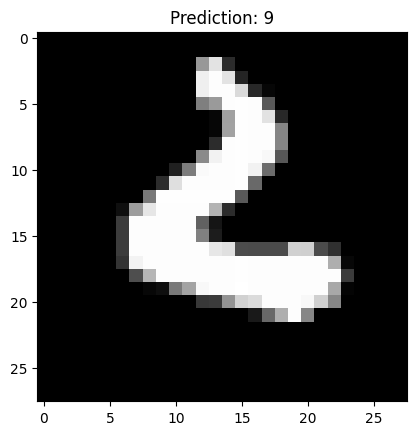


Step: 5000
Average Error: 0.8852671307817387


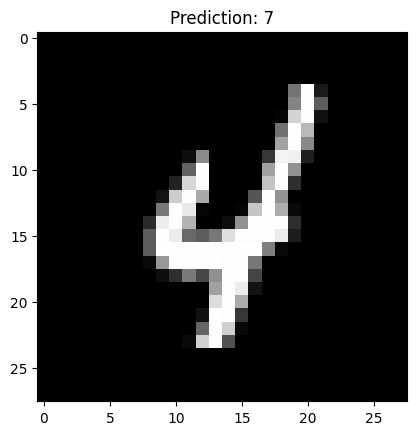


Step: 6000
Average Error: 0.8721121833333687


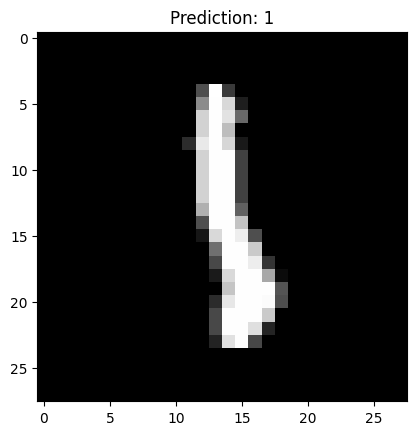


Step: 7000
Average Error: 0.849421624958898


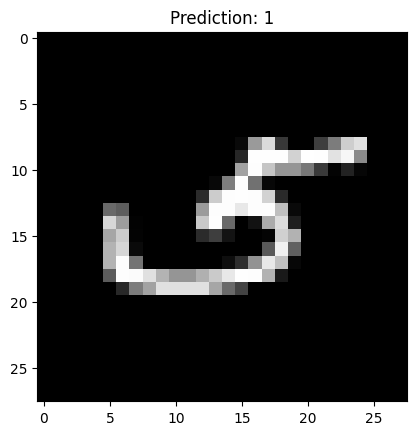


Step: 8000
Average Error: 0.8040709562856806


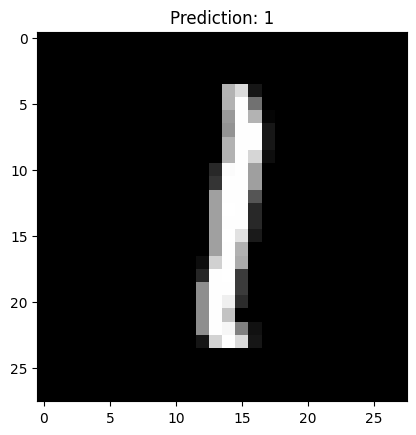


Step: 9000
Average Error: 0.7631247754604564


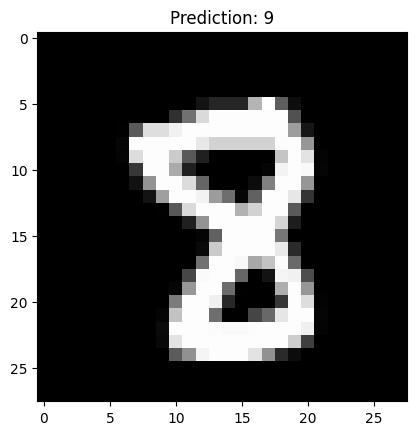


Step: 10000
Average Error: 0.7141185972810826


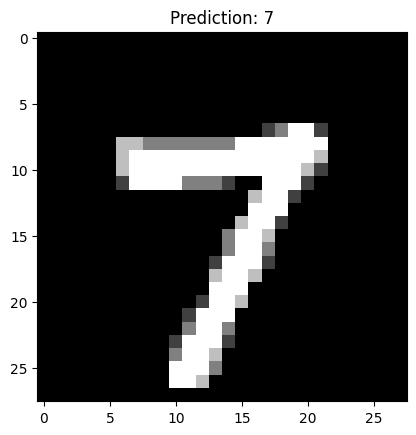


Step: 11000
Average Error: 0.6517085176451841


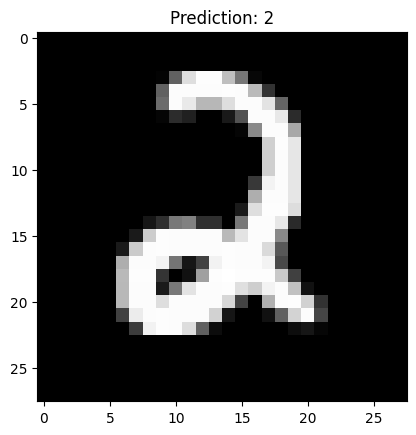


Step: 12000
Average Error: 0.6051471937945854


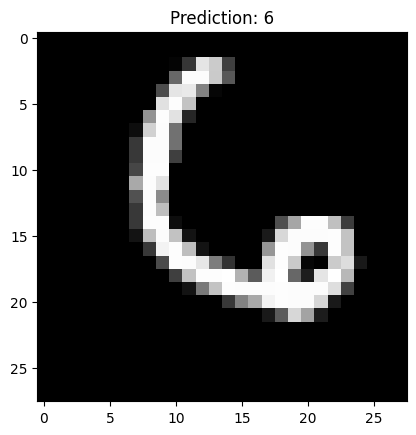


Step: 13000
Average Error: 0.5619641306393706


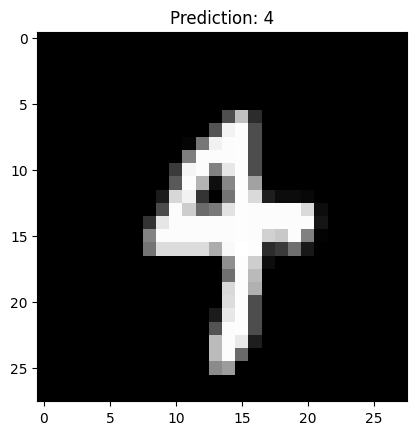


Step: 14000
Average Error: 0.5171597848082895


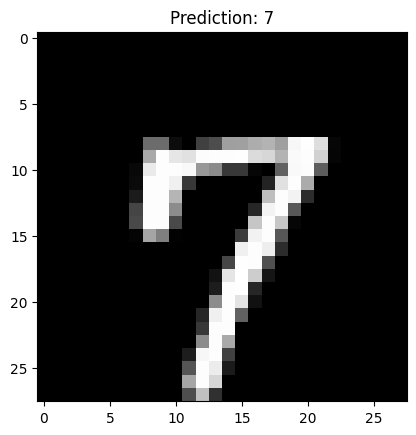


Step: 15000
Average Error: 0.4756298647678975


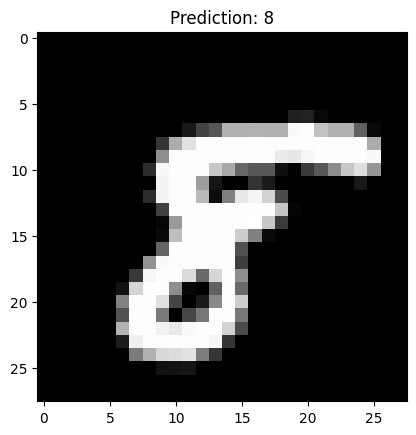


Step: 16000
Average Error: 0.45113648260702977


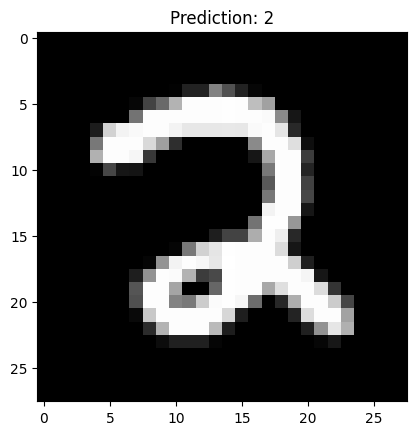


Step: 17000
Average Error: 0.4431942850661163


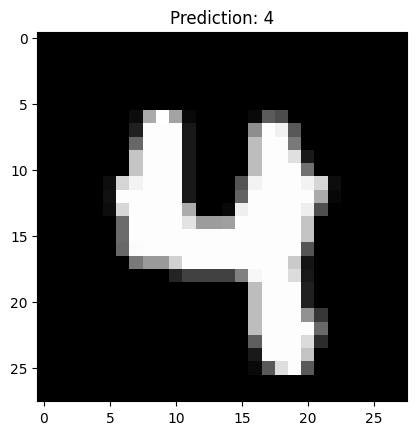


Step: 18000
Average Error: 0.42128612036746105


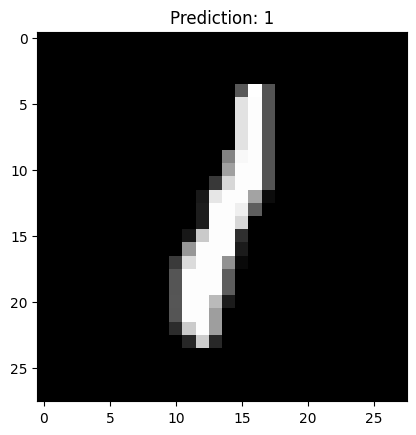


Step: 19000
Average Error: 0.4007191988027298


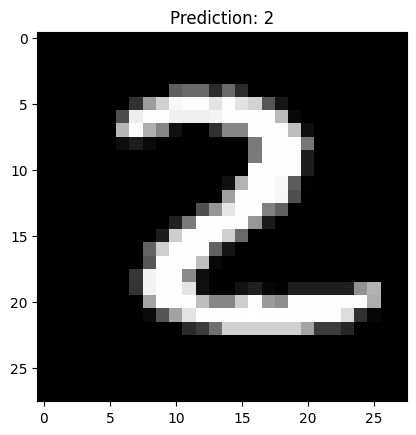


Step: 20000
Average Error: 0.377823687242697


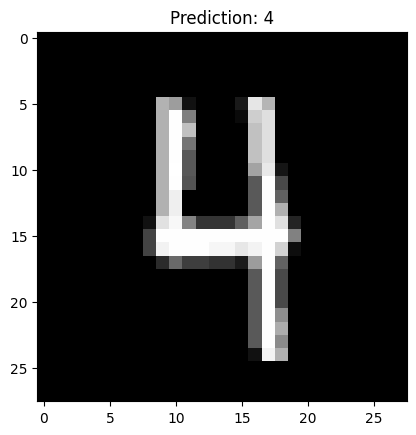


Step: 21000
Average Error: 0.3576995523863245


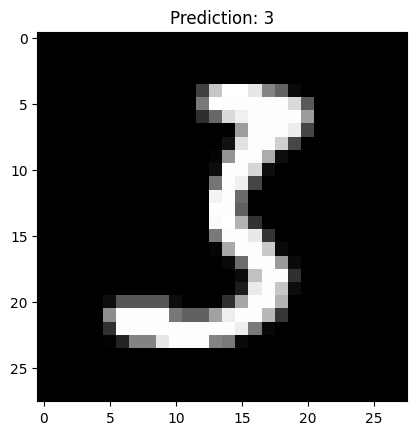


Step: 22000
Average Error: 0.33818389119790565


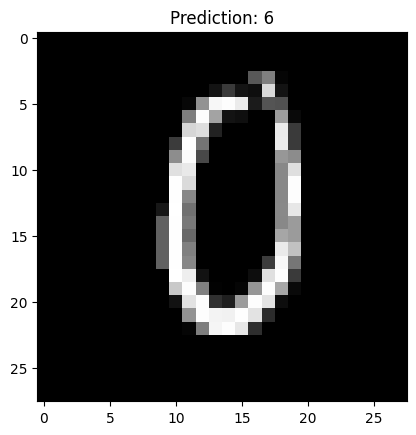


Step: 23000
Average Error: 0.3389776898097429


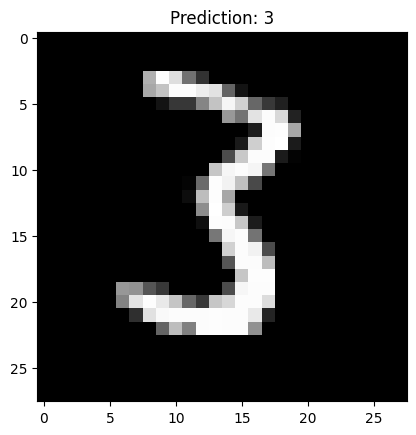


Step: 24000
Average Error: 0.32607071459897574


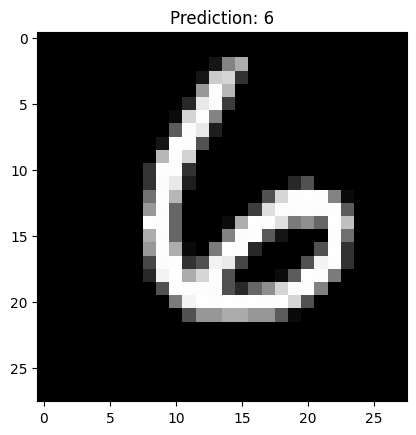


Step: 25000
Average Error: 0.3082947170691595


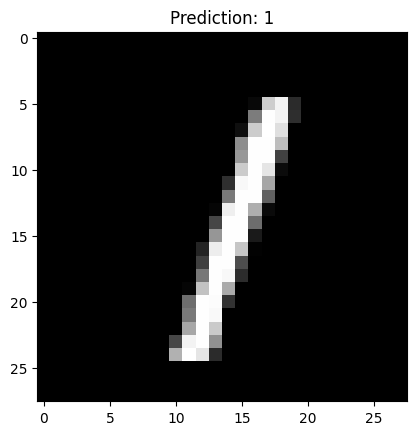


Step: 26000
Average Error: 0.32041799763037393


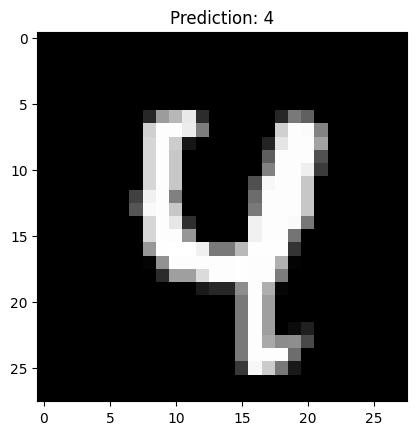


Step: 27000
Average Error: 0.2916677858032275


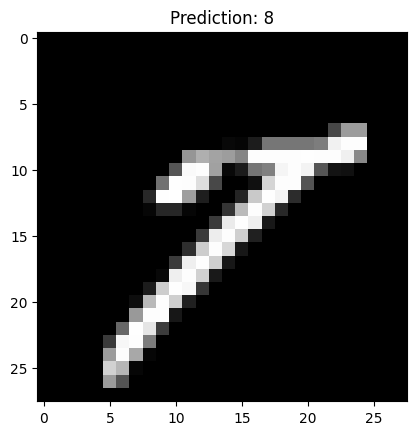


Step: 28000
Average Error: 0.284254699135759


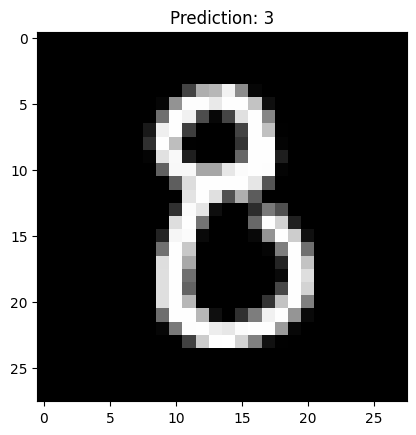


Step: 29000
Average Error: 0.29283632172020563


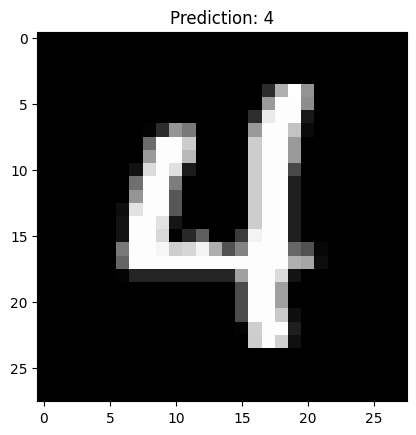

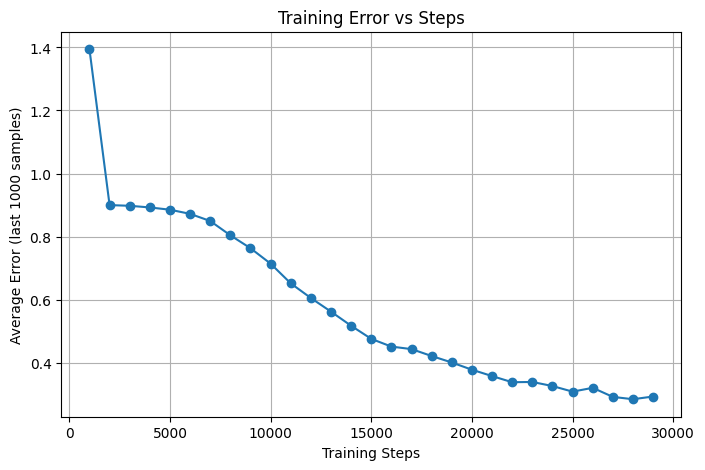

In [20]:
model = DNN([784,1250,10])
from collections import deque
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

error = deque(maxlen=1000)

# Store errors for plotting
steps = []
avg_errors = []

for n in range(30000):
    index = np.random.randint(0, 59998)
    error.append(model.train(x_train[index], encoded_labels[index]))

    # Every 1000 steps compute average error
    if n % 1000 == 0 and n > 0:
        avg_error = sum(error) / len(error)   # use current window
        steps.append(n)
        avg_errors.append(avg_error)

        print("\nStep:", n)
        print("Average Error:", avg_error)

        # Optional: visualize the current image + prediction
        plt.imshow(x_train[index].reshape(28,28), cmap="gray")
        plt.title(f"Prediction: {np.argmax(model.predict(x_train[index]))}")
        plt.show()

# --- Plot Error vs Steps ---
plt.figure(figsize=(8,5))
plt.plot(steps, avg_errors, marker="o")
plt.xlabel("Training Steps")
plt.ylabel("Average Error (last 1000 samples)")
plt.title("Training Error vs Steps")
plt.grid(True)
plt.show()


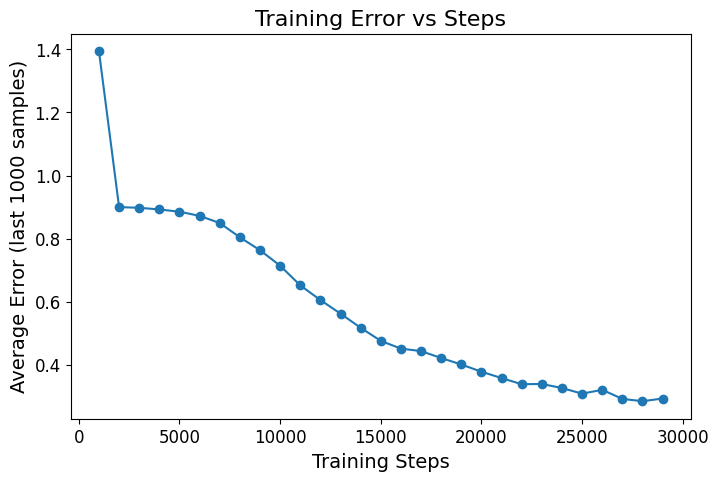

In [25]:
plt.figure(figsize=(8,5))
plt.plot(steps, avg_errors, marker="o")

plt.xlabel("Training Steps", fontsize=14)
plt.ylabel("Average Error (last 1000 samples)", fontsize=14)
plt.title("Training Error vs Steps", fontsize=16)

plt.tick_params(axis="both", labelsize=12)  # increase tick label size

plt.show()


In [22]:


test_data = pd.read_csv('MNIST_data/mnist_test.csv')
test_labels = np.array(test_data.iloc[:,0])
x_test = np.array(test_data.iloc[:,1:])/255

correct = 0

for i in range(len(test_data)):
    prediction = np.argmax(model.predict(x_test[i]))
    if prediction == test_labels[i]:
        correct +=1 
percent_correct = correct/len(test_data) * 100
print(percent_correct,'%') 

87.77000000000001 %



=== Training model with 1250 hidden neurons ===
Step 1000 | Hidden=1250 | Avg Error=1.3888
Step 2000 | Hidden=1250 | Avg Error=0.8980
Step 3000 | Hidden=1250 | Avg Error=0.8973
Step 4000 | Hidden=1250 | Avg Error=0.8895
Step 5000 | Hidden=1250 | Avg Error=0.8840
Step 6000 | Hidden=1250 | Avg Error=0.8653
Step 7000 | Hidden=1250 | Avg Error=0.8425
Step 8000 | Hidden=1250 | Avg Error=0.7980
Step 9000 | Hidden=1250 | Avg Error=0.7578
Step 10000 | Hidden=1250 | Avg Error=0.6959
Step 11000 | Hidden=1250 | Avg Error=0.6384
Step 12000 | Hidden=1250 | Avg Error=0.6039
Step 13000 | Hidden=1250 | Avg Error=0.5529
Step 14000 | Hidden=1250 | Avg Error=0.5120
Step 15000 | Hidden=1250 | Avg Error=0.4726
Step 16000 | Hidden=1250 | Avg Error=0.4402
Step 17000 | Hidden=1250 | Avg Error=0.4301
Step 18000 | Hidden=1250 | Avg Error=0.4144
Step 19000 | Hidden=1250 | Avg Error=0.3908
Step 20000 | Hidden=1250 | Avg Error=0.3810
Step 21000 | Hidden=1250 | Avg Error=0.3690
Step 22000 | Hidden=1250 | Avg Error

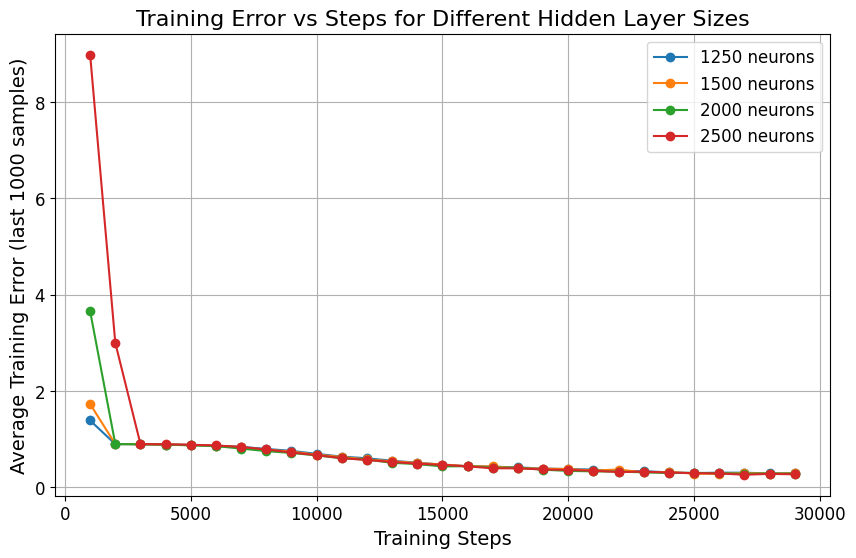

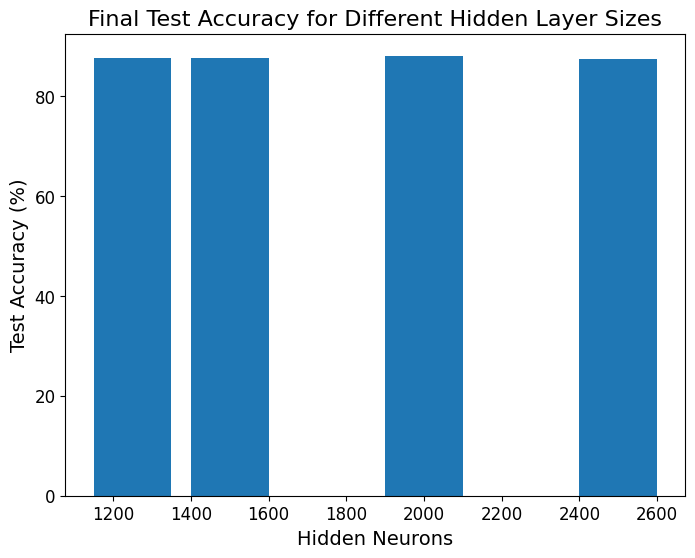

In [2]:
from collections import deque
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# --- Load test set ---
test_data = pd.read_csv('MNIST_data/mnist_test.csv')
test_labels = np.array(test_data.iloc[:, 0])
x_test = np.array(test_data.iloc[:, 1:]) / 255

# Different hidden layer sizes to test
hidden_sizes = [1250, 1500, 2000, 2500]

results = {}        # training curves
final_test_acc = {} # final test accuracies

for h in hidden_sizes:
    print(f"\n=== Training model with {h} hidden neurons ===")
    model = DNN([784, h, 10])   # new model

    error = deque(maxlen=1000)
    steps = []
    avg_errors = []

    for n in range(30000):
        index = np.random.randint(0, 59998)
        error.append(model.train(x_train[index], encoded_labels[index]))

        if n % 1000 == 0 and n > 0:
            avg_error = sum(error) / len(error)
            steps.append(n)
            avg_errors.append(avg_error)
            print(f"Step {n} | Hidden={h} | Avg Error={avg_error:.4f}")

    # --- Evaluate once after training completes ---
    correct = 0
    for i in range(len(test_data)):
        prediction = np.argmax(model.predict(x_test[i]))
        if prediction == test_labels[i]:
            correct += 1
    test_acc = correct / len(test_data) * 100
    final_test_acc[h] = test_acc
    print(f"Final Test Accuracy for {h} neurons: {test_acc:.2f}%")

    results[h] = (steps, avg_errors)

# --- Plot Training Error ---
plt.figure(figsize=(10,6))
for h, (steps, avg_errors) in results.items():
    plt.plot(steps, avg_errors, marker="o", label=f"{h} neurons")
plt.xlabel("Training Steps", fontsize=14)
plt.ylabel("Average Training Error (last 1000 samples)", fontsize=14)
plt.title("Training Error vs Steps for Different Hidden Layer Sizes", fontsize=16)
plt.legend(fontsize=12)
plt.tick_params(axis="both", labelsize=12)
plt.grid(True)
plt.show()

# --- Plot Final Test Accuracy ---
plt.figure(figsize=(8,6))
plt.bar(final_test_acc.keys(), final_test_acc.values(), width=200)
plt.xlabel("Hidden Neurons", fontsize=14)
plt.ylabel("Test Accuracy (%)", fontsize=14)
plt.title("Final Test Accuracy for Different Hidden Layer Sizes", fontsize=16)
plt.tick_params(axis="both", labelsize=12)
plt.show()

